## Importing Data

In [ ]:
# %pip install seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.6 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.3 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.3 MB 1.4 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.3 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.3 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.3 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.3 MB 1.3 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.3 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.3 MB 1.3 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.3 MB 1.3 MB/s eta 0:00:05
   --------------- ------------------------ 3.1/8.3 MB 1.3 MB/s eta 0:00:04
   ---------------- ------

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [12]:
# %pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------

In [13]:
# https://github.com/Tirru-2002/Movie-Recommendation-System-Deployment/blob/main/Movies_dataset_final_.xlsx
# use this link to download the dataset and place it in the specified path or update the path accordingly

ds = pd.read_excel("https://github.com/Tirru-2002/Movie-Recommendation-System-Deployment/raw/main/Movies_dataset_final_.xlsx")
ds = ds.sort_values(by='Year of Release')
ds

,Movie Name,Year of Release,Duration,Genre,Certificate,Movie Rating,Metascore,Description,Director,Stars,Votes,Gross
7569,Bluebeard,1901,12,"Short, Horror",TV-MA,6.9,NaN,A young woman becomes the eighth wife of the w...,['Georges Méliès'],"['Georges Méliès', ""Jehanne d'Alcy"", 'Bleuette...","1,834",NaN
0,A Trip to the Moon,1902,13,"Short, Action, Adventure",TV-G,8.2,NaN,A group of astronomers go on an expedition to ...,['Georges Méliès'],"['Georges Méliès', 'Victor André', 'Bleuette B...","54,487",NaN
1,The Great Train Robbery,1903,11,"Short, Action, Adventure",TV-G,7.3,NaN,A group of bandits stage a brazen train hold-u...,['Edwin S. Porter'],"[""Gilbert M. 'Broncho Billy' Anderson"", 'A.C. ...","20,603",NaN
6412,An Impossible Voyage,1904,24,"Short, Action, Adventure",Not Rated,7.5,NaN,"Using every known means of transportation, sev...",['Georges Méliès'],"['Georges Méliès', 'Fernande Albany', ""Jehanne...","3,883",NaN
1180,Dante's Inferno,1911,71,"Adventure, Drama, Fantasy",NaN,7.0,NaN,Loosely adapted from Dante's Divine Comedy and...,"['Francesco Bertolini', 'Adolfo Padovan', 'Giu...","['Salvatore Papa', 'Arturo Pirovano', 'Giusepp...","3,322",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
6293,Unconditional,IV 2012,92,"Biography, Crime, Drama",PG-13,7.0,NaN,A woman's idyllic life is shattered when her h...,['Brent McCorkle'],"['Lynn Collins', 'Michael Ealy', 'Bruce McGill...","4,943",1.01
5540,Split,IX 2016,117,"Horror, Thriller",PG-13,7.3,63.0,Three girls are kidnapped by a man with a diag...,['M. Night Shyamalan'],"['James McAvoy', 'Anya Taylor-Joy', 'Haley Lu ...","537,724",138.29
5822,Jackie,V 2016,100,"Biography, Drama",R,6.7,81.0,Following the assassination of President John ...,['Pablo Larraín'],"['Natalie Portman', 'Peter Sarsgaard', 'Greta ...","82,764",13.96
5011,Far From the Tree,V 2017,93,Documentary,Unrated,7.7,70.0,Based on the NY Times bestselling book by Andr...,"['Rachel Dretzin', 'Jamila Ephron']","['Amy Allnutt', 'Jack Allnutt', 'Harry Burdick...",629,0.16


In [14]:
#display columns
ds.columns

Index(['Movie Name', 'Year of Release', 'Duration', 'Genre', 'Certificate',
       'Movie Rating', 'Metascore', 'Description', 'Director', 'Stars',
       'Votes', 'Gross'],
      dtype='str')

In [15]:
#finding duplicates
ds.duplicated().sum()

np.int64(0)

## Data Transformation

In [16]:
# Before Column Transformation 
ds['Stars'][1]

'["Gilbert M. \'Broncho Billy\' Anderson", \'A.C. Abadie\', \'George Barnes\', \'Justus D. Barnes\']'

In [17]:
# Remove all non-numeric characters from 'Year of Release','Duration' and 'Votes' column
ds['Year of Release'] = ds['Year of Release'].str.replace('[^0-9]', '', regex=True)
ds['Duration'] = ds['Duration'].str.replace('[^0-9]', '', regex=True)
ds['Votes'] = ds['Votes'].str.replace('[^0-9]', '', regex=True)

# Assuming df is your DataFrame and 'directors' is the column containing the data
ds['Director'] = ds['Director'].str.replace(r'[\'\[\]]', '', regex=True)

# Remove commas from the 'Genre' column
ds['Genre'] = ds['Genre'].str.replace(',', '')

# Remove symbols, tokens, and characters except alphabets from 'Stars' column
import re
ds['Stars'] = ds['Stars'].apply(lambda x: re.sub(r'[^a-zA-Z.,\s]', '', x))

# Convert 'Year of Release','Duration' and 'Votes' to numeric
ds['Year of Release'] = pd.to_numeric(ds['Year of Release'], errors='coerce')
ds['Duration'] = pd.to_numeric(ds['Duration'], errors='coerce')
ds['Votes'] = pd.to_numeric(ds['Votes'], errors='coerce')

In [18]:
# Split the words in 'Stars' column on commas
ds['Stars'] = ds['Stars'].apply(lambda x: x.split(',') if isinstance(x, str) else [])

In [19]:
# After Column Transformation
ds['Stars'][1]

['Gilbert M. Broncho Billy Anderson',
 ' A.C. Abadie',
 ' George Barnes',
 ' Justus D. Barnes']

In [20]:
# Extract only the first two values from 'Stars' column
ds['Stars'] = ds['Stars'].apply(lambda x: x[0] if isinstance(x, list) else x)

In [21]:
# "stars" column after extracting only single value
ds['Stars'][1]

'Gilbert M. Broncho Billy Anderson'

In [22]:
# Assuming 'Year of Release' is the column with release years in your DataFrame ds
ds = ds[ds['Year of Release'] <= 2023]
ds['Year of Release']

7569    1901
0       1902
1       1903
6412    1904
1180    1911
        ... 
6293    2012
5540    2016
5822    2016
5011    2017
5015    2016
Name: Year of Release, Length: 7584, dtype: int64

###### Here 'Year of Release','Duration' and 'Votes' Features are Transformed into Numeric data by Eliminating mixed set of Symbols and alphabets.

###### operator("^") is used for pattern matching ,where replace('[^0-9]', '') except numeric all other values will be replaced with empty space.

###### Also extracting main cast(Hero) member from list of Stars , as single value feature is easy to perform analysis also to extract insights.

In [23]:
print("Dataset Information:")
print(ds.info())
print("\nNumber of missing values in each column:")
print(ds.isnull().sum())

Dataset Information:
<class 'pandas.DataFrame'>
Index: 7584 entries, 7569 to 5015
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Movie Name       7584 non-null   str    
 1   Year of Release  7584 non-null   int64  
 2   Duration         7583 non-null   float64
 3   Genre            7583 non-null   str    
 4   Certificate      5849 non-null   str    
 5   Movie Rating     7584 non-null   float64
 6   Metascore        3381 non-null   float64
 7   Description      7584 non-null   str    
 8   Director         7584 non-null   str    
 9   Stars            7584 non-null   str    
 10  Votes            7584 non-null   int64  
 11  Gross            3400 non-null   float64
dtypes: float64(4), int64(2), str(6)
memory usage: 2.4 MB
None

Number of missing values in each column:
Movie Name            0
Year of Release       0
Duration              1
Genre                 1
Certificate        1735
Movie Rating    

###### Above Features holds the valid Datatype , After the Transformation of Data where each feature posses valid datatype format and further no errors will arise due misclassification of datatype

In [24]:
# %pip install spacy textblob

In [25]:
# Text preprocessing function
import string
# import spacy
import nltk
from textblob import TextBlob
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    #Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tirum\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [26]:
# Sentiment analysis function
def analyze_sentiment(text):
    blob = TextBlob(text)
    
    # Get the sentiment polarity
    sentiment_polarity = blob.sentiment.polarity
    
    # Classify as high positive,low positive,high negative,low negative and neutral
    if sentiment_polarity >= 0.5:
        return 'high positive'
    elif 0 < sentiment_polarity < 0.5:
        return 'low positive'
    elif sentiment_polarity <= -0.5:
        return 'high negative'
    elif -0.5 < sentiment_polarity < 0:
        return 'low negative'
    else:
        return 'neutral'

# Apply preprocessing to the 'Description' column
ds['processed_description'] = ds['Description'].apply(preprocess_text)

# Apply sentiment analysis
ds['description_sentiment'] = ds['processed_description'].apply(analyze_sentiment)

# Print or save the results
print(ds[['Description', 'description_sentiment']])

                                            Description description_sentiment
7569  A young woman becomes the eighth wife of the w...          low positive
0     A group of astronomers go on an expedition to ...               neutral
1     A group of bandits stage a brazen train hold-u...          low positive
6412  Using every known means of transportation, sev...               neutral
1180  Loosely adapted from Dante's Divine Comedy and...          low positive
...                                                 ...                   ...
6293  A woman's idyllic life is shattered when her h...          low positive
5540  Three girls are kidnapped by a man with a diag...          low positive
5822  Following the assassination of President John ...          low negative
5011  Based on the NY Times bestselling book by Andr...          low positive
5015  This is a story about an IT worker called Denc...          low positive

[7584 rows x 2 columns]


###### From the anlysis we can conclude that wheather feature ds['Description'] is low positive,low negative,neutral,high positive,high negative 
###### As 'Description' is also transformed into categorical data object ,as it will enchance the predictions in process

## Data Cleaning

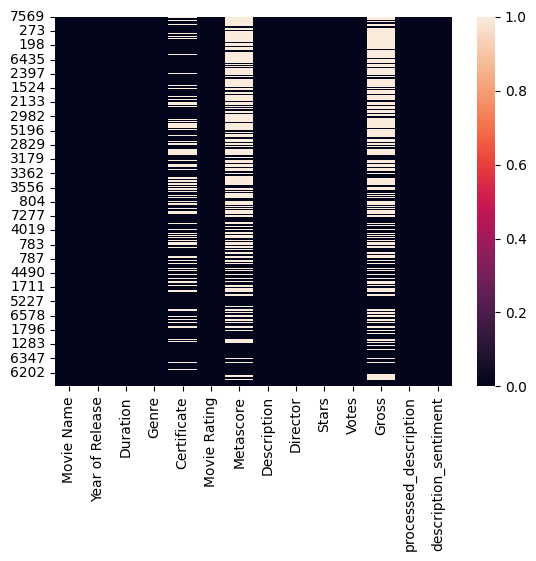

In [27]:
sns.heatmap(ds.isnull());

In [29]:
"""
Missing Data Analyzer for Data Engineering
Python Version: 3.11
Author: Data Engineering Script
Description: Analyzes missing data across all columns and provides recommendations
"""

import pandas as pd
import numpy as np
from typing import Union, Dict, List, Tuple
import sys


class MissingDataAnalyzer:
    """
    A class to analyze missing data in datasets and provide actionable recommendations.
    """
    
    def __init__(self, dataset: Union[pd.DataFrame, str]):
        """
        Initialize the analyzer with a dataset.
        
        Args:
            dataset: Either a pandas DataFrame or path to a CSV/Excel file
        """
        if isinstance(dataset, str):
            # Load dataset from file
            if dataset.endswith('.csv'):
                self.df = pd.read_csv(dataset)
            elif dataset.endswith(('.xlsx', '.xls')):
                self.df = pd.read_excel(dataset)
            else:
                raise ValueError("File must be CSV or Excel format")
        elif isinstance(dataset, pd.DataFrame):
            self.df = dataset
        else:
            raise TypeError("Dataset must be a pandas DataFrame or file path")
        
        self.total_rows = len(self.df)
        self.missing_analysis = {}
        
    def _count_missing_values(self, column: pd.Series) -> int:
        """
        Count missing values in a column including None, NaN, empty strings, and whitespace.
        
        Args:
            column: A pandas Series (column)
            
        Returns:
            Count of missing values
        """
        # Count None and NaN
        null_count = column.isna().sum()
        
        # For string columns, also count empty strings and whitespace
        if column.dtype == 'object':
            empty_count = (column.str.strip() == '').sum() if column.notna().any() else 0
            null_count += empty_count
            
        return null_count
    
    def _calculate_missing_percentage(self, missing_count: int) -> float:
        """
        Calculate the percentage of missing values.
        
        Args:
            missing_count: Number of missing values
            
        Returns:
            Percentage of missing values (rounded to 2 decimal places)
        """
        if self.total_rows == 0:
            return 0.0
        return round((missing_count / self.total_rows) * 100, 2)
    
    def _get_recommendation(self, percentage: float) -> Dict[str, str]:
        """
        Get recommendation based on missing data percentage.
        
        Args:
            percentage: Percentage of missing data
            
        Returns:
            Dictionary with category and recommendation
        """
        if percentage < 5:
            return {
                'category': '< 5% missing',
                'severity': 'LOW',
                'recommendation': 'Simple imputation methods (mean/median/mode) are usually sufficient',
                'action': 'SAFE TO IMPUTE'
            }
        elif 5 <= percentage < 15:
            return {
                'category': '5-15% missing',
                'severity': 'MODERATE',
                'recommendation': 'Consider more advanced methods like multiple imputation',
                'action': 'USE ADVANCED IMPUTATION'
            }
        elif 15 <= percentage <= 40:
            return {
                'category': '15-40% missing',
                'severity': 'HIGH',
                'recommendation': 'Use sophisticated methods like model-based imputation with caution',
                'action': 'CAUTION REQUIRED'
            }
        else:  # > 40%
            return {
                'category': '> 40% missing',
                'severity': 'CRITICAL',
                'recommendation': 'Consider whether to keep the variable at all (may introduce too much bias)',
                'action': 'CONSIDER DROPPING'
            }
    
    def analyze(self) -> Dict[str, Dict]:
        """
        Analyze missing data for all columns in the dataset.
        
        Returns:
            Dictionary containing analysis results for each column
        """
        for column_name in self.df.columns:
            column = self.df[column_name]
            
            # Count missing values
            missing_count = self._count_missing_values(column)
            
            # Calculate percentage
            missing_percentage = self._calculate_missing_percentage(missing_count)
            
            # Get recommendation
            recommendation = self._get_recommendation(missing_percentage)
            
            # Store analysis
            self.missing_analysis[column_name] = {
                'total_values': self.total_rows,
                'missing_count': missing_count,
                'valid_count': self.total_rows - missing_count,
                'missing_percentage': missing_percentage,
                'data_type': str(column.dtype),
                **recommendation
            }
        
        return self.missing_analysis
    
    def print_summary(self) -> None:
        """
        Print a formatted summary of the missing data analysis.
        """
        if not self.missing_analysis:
            self.analyze()
        
        print("=" * 100)
        print("MISSING DATA ANALYSIS REPORT".center(100))
        print("=" * 100)
        print(f"\nTotal Rows in Dataset: {self.total_rows:,}")
        print(f"Total Columns: {len(self.df.columns)}")
        print("\n" + "=" * 100)
        
        # Group columns by severity
        severity_groups = {'LOW': [], 'MODERATE': [], 'HIGH': [], 'CRITICAL': []}
        
        for col_name, analysis in self.missing_analysis.items():
            severity_groups[analysis['severity']].append((col_name, analysis))
        
        # Print each severity group
        for severity in ['LOW', 'MODERATE', 'HIGH', 'CRITICAL']:
            if severity_groups[severity]:
                print(f"\n{'=' * 100}")
                print(f"SEVERITY: {severity}".center(100))
                print(f"{'=' * 100}\n")
                
                for col_name, analysis in severity_groups[severity]:
                    self._print_column_analysis(col_name, analysis)
    
    def _print_column_analysis(self, column_name: str, analysis: Dict) -> None:
        """
        Print detailed analysis for a single column.
        
        Args:
            column_name: Name of the column
            analysis: Analysis dictionary for the column
        """
        print(f"Column: {column_name}")
        print(f"  Data Type: {analysis['data_type']}")
        print(f"  Missing Values: {analysis['missing_count']:,} out of {analysis['total_values']:,}")
        print(f"  Missing Percentage: {analysis['missing_percentage']}%")
        print(f"  Category: {analysis['category']}")
        print(f"  Recommendation: {analysis['recommendation']}")
        print(f"  Suggested Action: {analysis['action']}")
        print("-" * 100)
    
    def get_summary_dataframe(self) -> pd.DataFrame:
        """
        Get the analysis results as a pandas DataFrame.
        
        Returns:
            DataFrame with analysis results sorted by missing percentage (descending)
        """
        if not self.missing_analysis:
            self.analyze()
        
        df_summary = pd.DataFrame.from_dict(self.missing_analysis, orient='index')
        df_summary.index.name = 'column_name'
        df_summary = df_summary.reset_index()
        
        # Sort by missing percentage (descending)
        df_summary = df_summary.sort_values('missing_percentage', ascending=False)
        
        return df_summary
    
    def export_report(self, output_path: str = 'missing_data_report.csv') -> None:
        """
        Export the analysis report to a CSV file.
        
        Args:
            output_path: Path to save the CSV file
        """
        summary_df = self.get_summary_dataframe()
        summary_df.to_csv(output_path, index=False)
        print(f"\nReport exported successfully to: {output_path}")


def main():
    """
    Main function to demonstrate usage of the MissingDataAnalyzer.
    """
    
    # Example 2: Analyze the dataset
    analyzer = MissingDataAnalyzer(ds)  # ds is the DataFrame loaded earlier
    
    # Perform analysis
    results = analyzer.analyze()
    
    # Print formatted summary
    analyzer.print_summary()
    
    # Export report
    analyzer.export_report('missing_data_report.csv')
    
    # Get summary as DataFrame
    summary_df = analyzer.get_summary_dataframe()
    print("\n" + "=" * 100)
    print("SUMMARY TABLE (sorted by missing percentage)")
    print("=" * 100)
    print(summary_df.to_string(index=False))


if __name__ == "__main__":
    main()

                                    MISSING DATA ANALYSIS REPORT                                    

Total Rows in Dataset: 7,584
Total Columns: 14


                                           SEVERITY: LOW                                            

Column: Movie Name
  Data Type: str
  Missing Values: 0 out of 7,584
  Missing Percentage: 0.0%
  Category: < 5% missing
  Recommendation: Simple imputation methods (mean/median/mode) are usually sufficient
  Suggested Action: SAFE TO IMPUTE
----------------------------------------------------------------------------------------------------
Column: Year of Release
  Data Type: int64
  Missing Values: 0 out of 7,584
  Missing Percentage: 0.0%
  Category: < 5% missing
  Recommendation: Simple imputation methods (mean/median/mode) are usually sufficient
  Suggested Action: SAFE TO IMPUTE
----------------------------------------------------------------------------------------------------
Column: Duration
  Data Type: float64
  Missing Values

#### Droping Duplicates

In [30]:
# As 'Metascore','Gross' posses null values greater than average of total 7586 entries ,so futher imputation could arise higher error rate and misclassification
# Dropping columns which are having greater null values
ds = ds.drop(columns=['Metascore','Gross','Certificate'])

In [31]:
ds.drop_duplicates(inplace=True)
ds.shape

(7584, 11)

#### Imputation(Handling null values)

##### Filling "nan" values with mode value

In [32]:
# Null values in genre is '1' , so it is possible and easy to handle null values
ds['Genre'] = ds['Genre'].fillna(list(ds['Genre'].mode())[0].strip())

##### Filling "nan" values with mean value

In [33]:
# Null values in duration is '1', so it is possible and easy to handle null values
ds['Duration'] = ds['Duration'].fillna(ds['Duration'].mean())

In [34]:
ds.isnull().sum()

Movie Name               0
Year of Release          0
Duration                 0
Genre                    0
Movie Rating             0
Description              0
Director                 0
Stars                    0
Votes                    0
processed_description    0
description_sentiment    0
dtype: int64

In [35]:
# 1. Save the DataFrame to a CSV file
from importlib_metadata import files


ds.to_csv('movies_dataset(deploy).csv', index=False)


ModuleNotFoundError: No module named 'importlib_metadata'

In [37]:

import nltk

# Download the stopwords corpus
nltk.download('stopwords')

# It is highly likely you will also need the tokenizer, so download these too:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tirum\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tirum\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tirum\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [38]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [39]:
# Function to remove stopwords
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = word_tokenize(text)
    filtered_text = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_text)

In [41]:
# Apply remove_stopwords to the specified columns
columns_to_process = ['Movie Name', 'Description']
ds[columns_to_process] = ds[columns_to_process].map(remove_stopwords)

In [42]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tirum\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [43]:
# Function to perform lemmatization on a given text
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

In [44]:
# Applying lemmatization to the 'Description' column
ds['Description'] = ds['Description'].apply(lemmatize_text)

In [45]:
# Assuming df is your DataFrame and 'column_name' is the name of the column
# futher analysis will be done on below five features
rat = ds['Movie Rating'].value_counts()
gen = ds['Genre'].value_counts()
dirc = ds['Director'].value_counts()
star = ds['Stars'].value_counts()
sentiments = ds['description_sentiment'].value_counts()
print(f'{rat}\n\n {gen}\n\n {dirc}\n\n {star}\n\n {sentiments}')

Movie Rating
7.5    773
7.3    661
7.4    654
7.2    638
7.6    638
7.1    606
7.0    512
7.7    493
7.8    390
6.9    341
7.9    277
8.0    248
8.1    219
6.8    212
6.7    179
8.2    132
6.6    114
8.3     91
6.5     86
8.4     54
8.5     49
6.4     47
8.6     32
8.7     23
6.2     22
6.1     17
6.3     16
8.8     14
8.9     11
6.0      8
9.0      7
5.8      3
5.3      3
9.2      2
5.9      2
9.4      2
5.6      2
5.5      1
9.5      1
9.3      1
5.1      1
5.4      1
4.8      1
Name: count, dtype: int64

 Genre
Drama                                    1124
Drama Romance                             494
Comedy Drama                              353
Comedy Drama Romance                      269
Comedy                                    225
                                         ... 
Adventure Biography Crime                   1
Music Mystery Thriller                      1
Biography Crime Thriller                    1
Documentary Drama History                   1
Drama Horror Music  

###### Features 'Certificate','Movie Rating','Genre','Director' ,'Stars'  and 'description_sentiment' are holding Categorical Data , which are futher taken to visualization ,processing and predictions

In [46]:
# %pip install bokeh

In [ ]:
# %pip install plotly

In [35]:
import plotly.express as px
column_names = ['Genre','Movie Rating','Director','Stars','description_sentiment']
# Assuming 'column_names' is a list of column names
for column_name in column_names:
    fig = px.histogram(ds, x=column_name, nbins=50, title=f'Histogram of {column_name}')
    fig.show()


In [36]:
ds = ds.sort_index()

In [37]:
# Assuming 'Movie Rating' is the column with the genres in your DataFrame ds
counts = ds['Movie Rating'].value_counts()

# Get the Movie Rating with a count of more than 20
Movie_Rating_20 = counts[counts > 20]

print(Movie_Rating_20)

Movie Rating
7.5    773
7.3    661
7.4    654
7.2    638
7.6    638
7.1    606
7.0    512
7.7    493
7.8    390
6.9    341
7.9    277
8.0    248
8.1    219
6.8    212
6.7    179
8.2    132
6.6    114
8.3     91
6.5     86
8.4     54
8.5     49
6.4     47
8.6     32
8.7     23
6.2     22
Name: count, dtype: int64


In [38]:
# Assuming 'Director' is the column with the genres in your DataFrame ds
counts = ds['Director'].value_counts()

# Get the genres with a count of more than 200
Director_over_20 = counts[counts > 20]

print(Director_over_20)

Director
Fritz Lang          29
Martin Scorsese     26
Woody Allen         25
Ingmar Bergman      24
Michael Curtiz      24
Satyajit Ray        24
William Wyler       23
Alfred Hitchcock    22
Yasujirô Ozu        22
Luis Buñuel         21
                    21
John Ford           21
Name: count, dtype: int64


In [39]:
# Assuming 'Stars' is the column with the genres in your DataFrame ds
counts = ds['Stars'].value_counts()

# Get the stars with a count of more than 15
stars_over_15 = counts[counts > 15]

print(stars_over_15)

Stars
Burt Lancaster          26
Bette Davis             26
Cary Grant              26
James Stewart           25
John Wayne              25
Humphrey Bogart         23
Spencer Tracy           22
Gregory Peck            21
Paul Newman             20
Jean Gabin              20
Robert De Niro          20
Marcello Mastroianni    19
Clint Eastwood          19
Gary Cooper             19
Tom Hanks               17
Woody Allen             16
Marlon Brando           16
James Cagney            16
Al Pacino               16
Toshir Mifune           16
Name: count, dtype: int64


In [40]:
# Genre
# Assuming 'Genre' is the column with the genres in your DataFrame ds
counts = ds['Genre'].value_counts()

# Get the genres with a count of more than 100
genres_over_100 = counts[counts > 100]

print(genres_over_100)

Genre
Drama                                  1124
Drama Romance                           494
Comedy Drama                            353
Comedy Drama Romance                    269
Comedy                                  225
Crime Drama                             175
Drama War                               161
Documentary                             148
Crime Drama Thriller                    147
Crime Drama Film-Noir                   121
Crime Drama Mystery                     113
Comedy Romance                          110
Action Crime Drama                      110
Biography Drama History                 107
Drama Thriller                          102
Name: count, dtype: int64


In [41]:
high_rmovie = []
for index, rating in enumerate(ds['Movie Rating']):
    if rating > 7.0:
        print(f"Index: {index}, Movie Rating: {rating}")
        high_rmovie.append(index)  # Append the index to the list if needed


Index: 0, Movie Rating: 8.2
Index: 1, Movie Rating: 7.3
Index: 2, Movie Rating: 7.3
Index: 3, Movie Rating: 7.7
Index: 4, Movie Rating: 7.2
Index: 5, Movie Rating: 7.2
Index: 6, Movie Rating: 8.0
Index: 7, Movie Rating: 7.3
Index: 8, Movie Rating: 7.1
Index: 9, Movie Rating: 8.2
Index: 10, Movie Rating: 8.0
Index: 11, Movie Rating: 7.8
Index: 12, Movie Rating: 7.6
Index: 13, Movie Rating: 7.6
Index: 14, Movie Rating: 7.8
Index: 15, Movie Rating: 7.5
Index: 16, Movie Rating: 8.1
Index: 17, Movie Rating: 8.0
Index: 18, Movie Rating: 8.0
Index: 19, Movie Rating: 7.2
Index: 20, Movie Rating: 8.0
Index: 21, Movie Rating: 7.6
Index: 22, Movie Rating: 8.2
Index: 23, Movie Rating: 7.7
Index: 24, Movie Rating: 7.9
Index: 25, Movie Rating: 7.8
Index: 26, Movie Rating: 7.9
Index: 27, Movie Rating: 7.5
Index: 28, Movie Rating: 8.1
Index: 29, Movie Rating: 7.5
Index: 30, Movie Rating: 7.8
Index: 31, Movie Rating: 7.6
Index: 32, Movie Rating: 7.8
Index: 33, Movie Rating: 8.1
Index: 35, Movie Rating:

### Filtering Methods
##### (using 'Movie Rating' & 'Director' )

In [42]:
# Assuming 'Stars' is the column with stars in your DataFrame ds
# Assuming both Movie_Rating_20 and Director_over_20 are already calculated

# Create boolean masks for filtering
mask_rating = ds['Movie Rating'].isin(high_rmovie)
mask_director = ds['Director'].isin(Director_over_20.index)

# Apply boolean indexing to get rows where both conditions are met
filtered_ds = ds[mask_rating & mask_director]

# Display the resulting DataFrame
print(filtered_ds[['Movie Rating', 'Director', 'Movie Name','Stars']])


      Movie Rating          Director                     Movie Name  \
135            7.0  Alfred Hitchcock                       Sabotage   
282            7.0        Fritz Lang                    Clash Night   
358            7.0         John Ford                     Rio Grande   
363            8.0       Luis Buñuel            Exterminating Angel   
443            8.0     William Wyler                  Roman Holiday   
462            8.0      Yasujirô Ozu               Autumn Afternoon   
491            8.0    Ingmar Bergman                          Shame   
493            8.0    Ingmar Bergman                   Winter Light   
494            8.0    Ingmar Bergman                  Virgin Spring   
495            8.0    Ingmar Bergman               Cries & Whispers   
535            8.0      Satyajit Ray                       Stranger   
536            8.0      Satyajit Ray                Distant Thunder   
1295           8.0       Woody Allen                     Annie Hall   
1477  

Here we have extracted Stars,Movie names with minimum of movie rating '7.0' and directors with frequency count of minimum '20'.

This is one of the way to extract valuable information from the dataset by Filtering the Features and values with it....

# Data Visualization

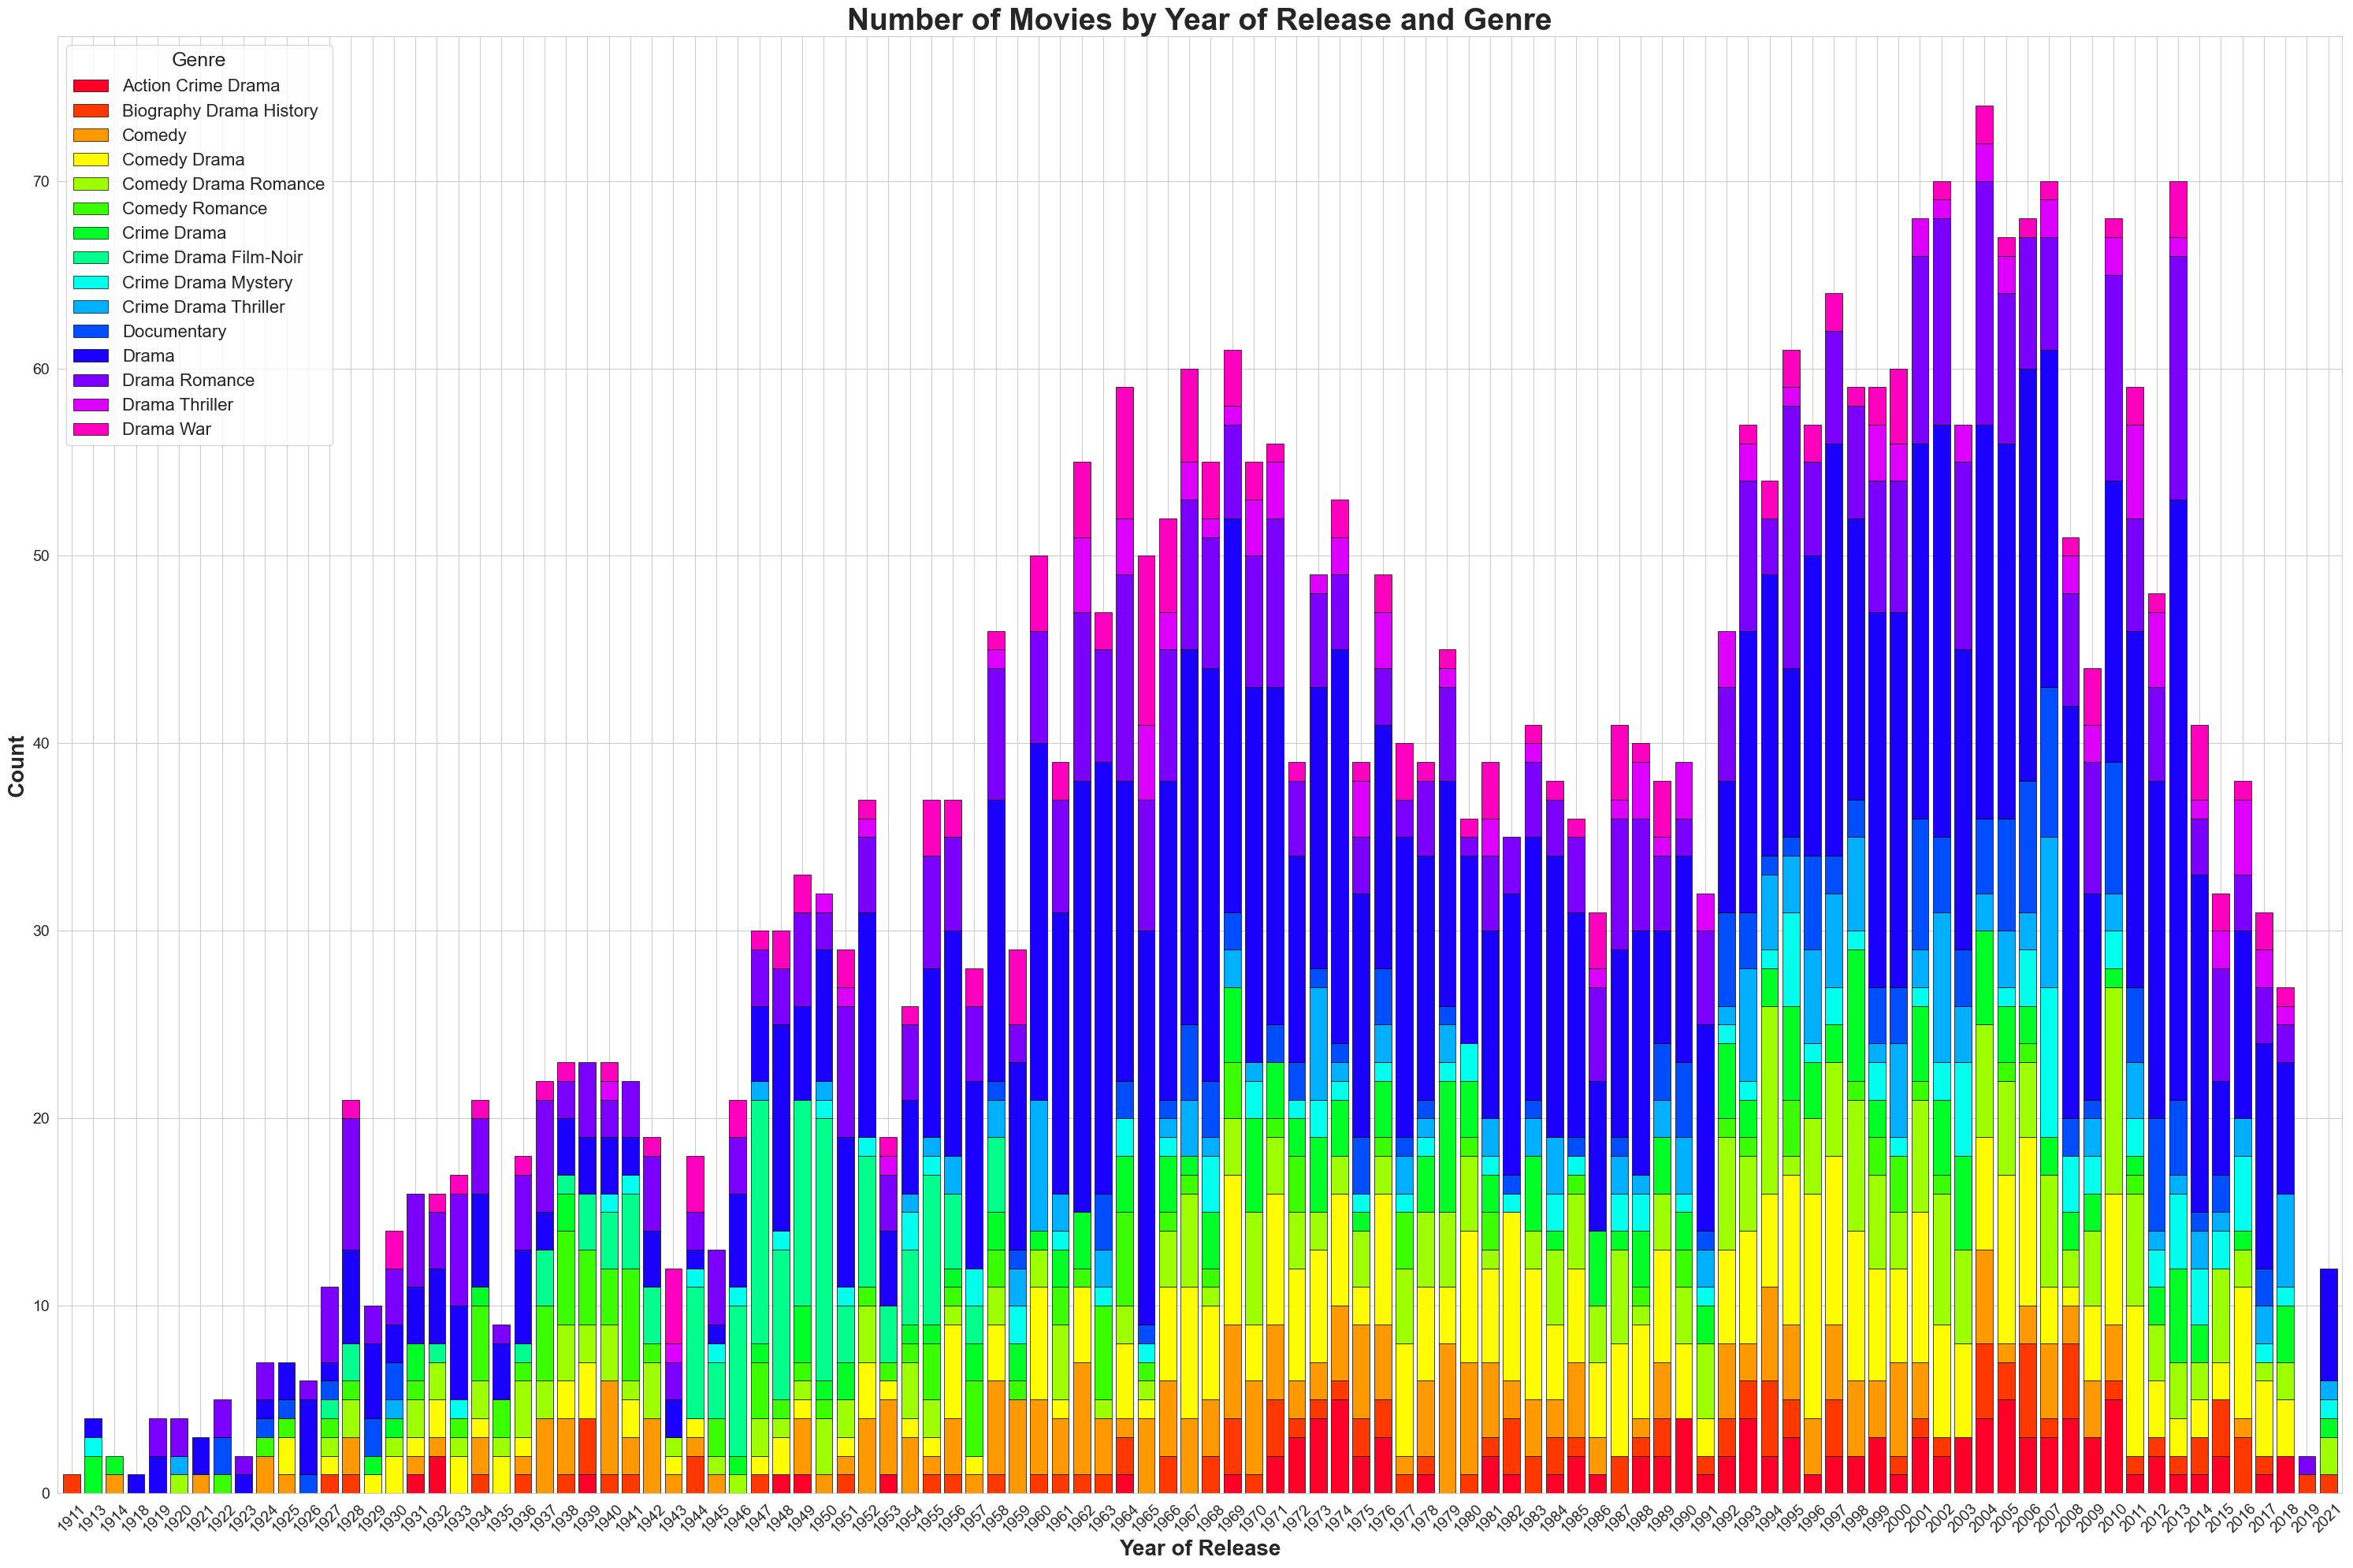

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns # Optional: helps with setting aesthetic themes

# Optional: Set a white background grid style for better contrast
sns.set_style("whitegrid")

# 1. Create the list of specific genres
genres = []
for i in genres_over_100.index.tolist():
    genres.append(i.strip())

# 2. Filter the dataframe to only keep rows where the Genre is in your list
ds['Genre'] = ds['Genre'].astype(str).str.strip() 
filtered_ds = ds[ds['Genre'].isin(genres)]

# 3. Group by 'Year of Release' and 'Genre'
grouped = filtered_ds.groupby(['Year of Release', 'Genre']).size()

# 4. Unstack to prepare for plotting
plot_data = grouped.unstack(fill_value=0)

# 5. Plot with a BRIGHT colormap
# 'gist_rainbow', 'hsv', or 'nipy_spectral' are excellent for high brightness
plot_data.plot(kind='bar', 
               stacked=True, 
               figsize=(30, 20), 
               cmap='gist_rainbow', # <--- Specifies the bright colour palette
               width=0.8,           # Makes bars slightly wider
               edgecolor='black',   # Adds a black border to bars to separate colours
               linewidth=0.5)

plt.xlabel('Year of Release', fontsize=20, fontweight='bold')
plt.ylabel('Count', fontsize=20, fontweight='bold')
plt.title('Number of Movies by Year of Release and Genre', fontsize=28, fontweight='bold')

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Adjust legend to be outside if it blocks data, or nice and big
plt.legend(title='Genre', title_fontsize=18, fontsize=16, loc='upper left')

plt.tight_layout()
plt.show()

1).Increase in Movie Production: There’s a significant increase in movie production from around 1990 onwards. This could be due to advancements in technology and the growth of the film industry.

2).Dominance of “R” Rated Movies: “R” rated movies (represented by red bars) have been consistently high in number every year. This suggests that movies with “R” rating are popular among filmmakers.

3).Variety of Certificates Over Time: Over the years, the variety of certificates for movies has increased, indicating a diversification in the types of content being produced.

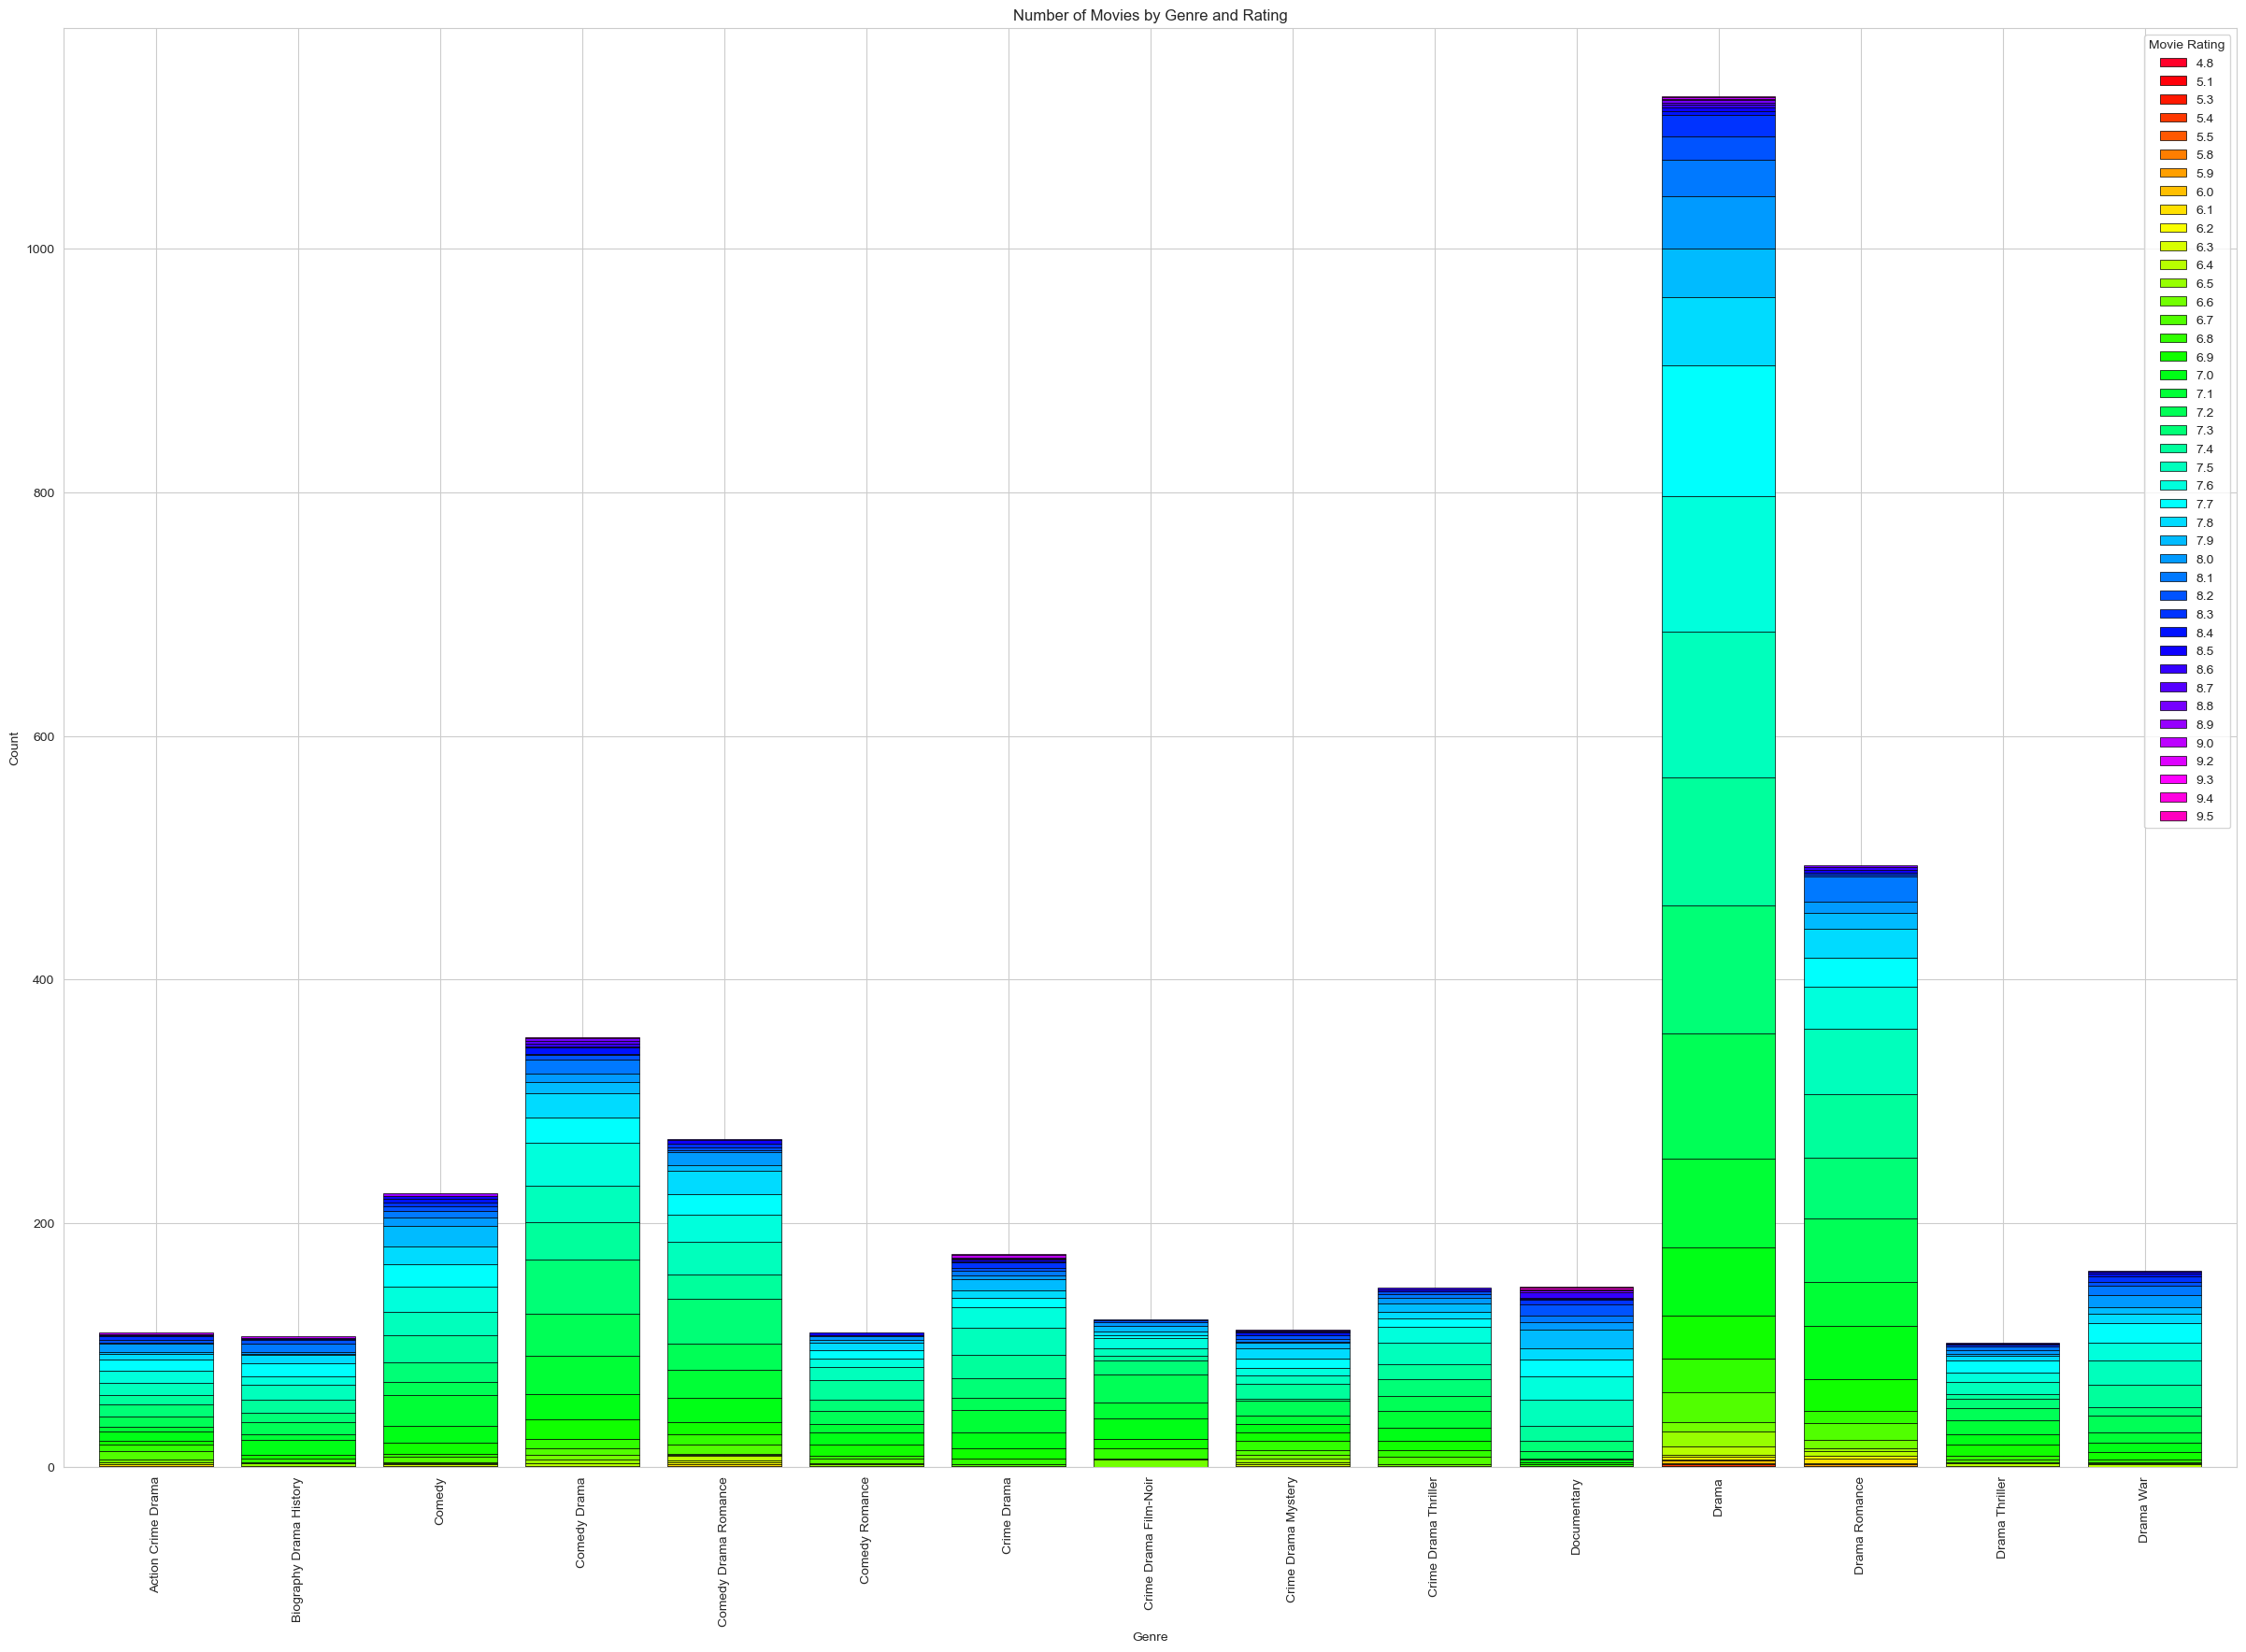

In [63]:
# Group by 'Genre' and 'Rating' and count the number of movies in each group
grouped = filtered_ds.groupby(['Genre', 'Movie Rating']).size()

# Unstack the grouped DataFrame and plot it
# 4. Unstack to prepare for plotting
plot_data = grouped.unstack(fill_value=0)

# 5. Plot with a BRIGHT colormap
# 'gist_rainbow', 'hsv', or 'nipy_spectral' are excellent for high brightness
plot_data.plot(kind='bar', 
               stacked=True, 
               figsize=(30, 20), 
               cmap='gist_rainbow', # <--- Specifies the bright colour palette
               width=0.8,           # Makes bars slightly wider
               edgecolor='black',   # Adds a black border to bars to separate colours
               linewidth=0.5)

# grouped.unstack().plot(kind='bar', stacked=True, figsize=(100,15))

plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Number of Movies by Genre and Rating')

plt.show()


Drama                                  1125

Drama Romance                           494

Comedy Drama                            354

Comedy Drama Romance                    269

Comedy                                  225

Crime Drama                             175

Drama War                               161 

( reported as higher no.of frequency )

1).R-rated Dominance: The majority of the movies in your dataset (47.8%) are R-rated. This suggests a significant amount of adult content.

2).Not Rated Movies: The second largest segment is movies that are not rated, making up 21.7% of your dataset. This could indicate a large number of older or independent films that haven’t been officially rated.

## DATA EXPLORATION
DATA GROSS IN YEARS¶

In [65]:
# import plotly.graph_objects as go
# gross_year = ds.groupby('Year of Release')['Gross'].sum()

# fig = go.Figure()
# fig.add_trace(go.Scatter(x=gross_year.index, y=gross_year.values,
#                     mode='lines',marker_color='blue',name='Gross income by Year'))


# fig.update_layout(title_text='Money Statistics')
# fig.add_annotation(
#             x=2020,
#             y=gross_year.values.max(),
#             text="Peak")

# fig.show()


Becasue of presence of many null values in Gross feature ,encountered the improper graph
:- above graphs give information about trend of no.of movies released on year until 2019.

In [ ]:
# %pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 15.7 MB/s eta 0:00:0000:01


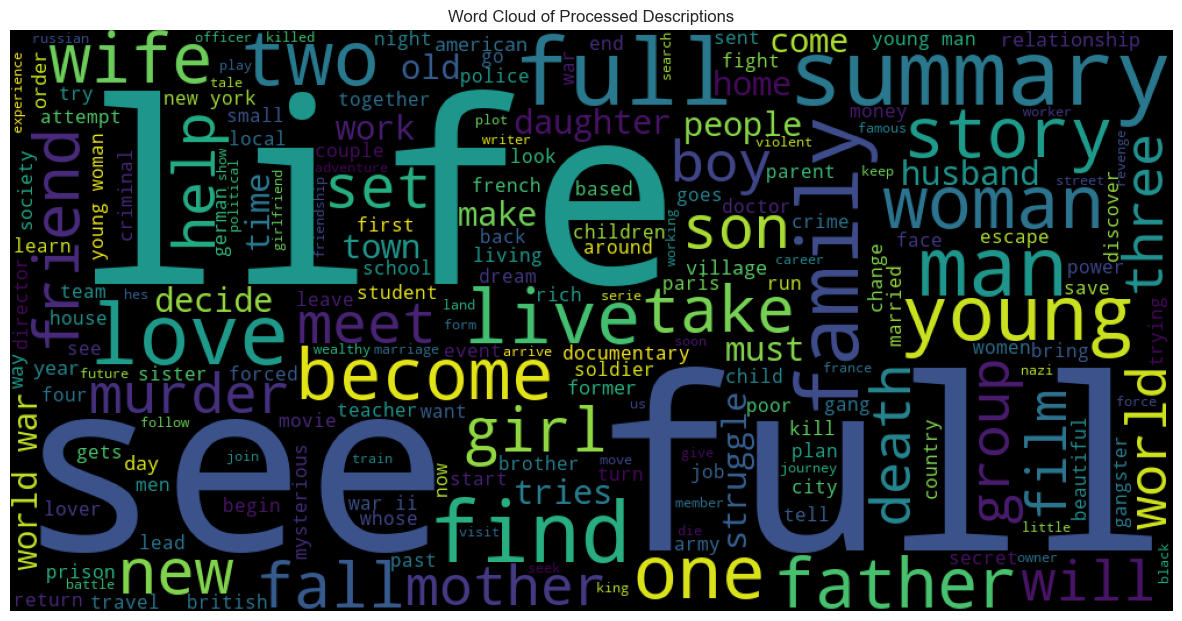

In [68]:
# Processed Description and Sentiment
# For word cloud, you need the wordcloud library. You can install it using pip install wordcloud
from wordcloud import WordCloud

plt.figure(figsize=(15,10))
wordcloud = WordCloud(width = 1000, height = 500).generate(' '.join(ds['processed_description']))
plt.imshow(wordcloud)
plt.title('Word Cloud of Processed Descriptions')
plt.axis("off")
plt.show()

## 1)how many movies reased in each year?

In [59]:
ds['Year of Release'].value_counts().sort_index()

1901     1
1902     1
1903     1
1904     1
1911     2
        ..
2017    76
2018    74
2019    11
2020     1
2021    29
Name: Year of Release, Length: 113, dtype: int64

## 2)which are the top rated movies in data?

In [60]:
# Sort the DataFrame by 'Movie Rating' column in descending order
top_rated_movies = ds.sort_values(by='Movie Rating', ascending=False)
top_rated_movies.head()[['Movie Name', 'Movie Rating']]

,Movie Name,Movie Rating
817,Svet Koji Nestaje,9.5
816,"Disappearing Oasis , Last Oasis",9.4
1494,Band Brothers,9.4
1222,Shawshank Redemption,9.3
3371,Chaos Class,9.2


## 3)In which year more movies released?

In [61]:
released_years = ds['Year of Release'].value_counts().head()
released_years

2004    148
2007    141
2010    133
2002    132
2013    129
Name: Year of Release, dtype: int64

## 4)Which movies have the highest gross income?

In [ ]:
# Use nlargest to get the top 5 movies based on 'Gross' income
# top_grossing_movies = ds.nlargest(5, 'Gross')
# top_grossing_movies.head()[['Movie Name', 'Gross']]

,Movie Name,Gross
7473,Incredibles 2,608.58
7308,Dark Knight,534.86
7390,Dark Knight Rises,448.14
902,Shrek 2,436.47
875,E.T .,435.11


## 5) Who are the top 5 directors and stars based on the average rating of their movies?

In [69]:
# Group by 'Director' and calculate the average rating for each director
avg_rating_directors = ds.groupby('Director')['Movie Rating'].mean()
top_directors = avg_rating_directors.nlargest(5)
top_directors.head()

Director
Scott Grimes, Damian Lewis, Ron Livingston    9.400000
Amitabh Reza Chowdhury                        9.000000
Petar Lalovic                                 8.966667
Ezra Edelman                                  8.900000
Henry Arnold, Salome Kammer, Frank Röth       8.900000
Name: Movie Rating, dtype: float64

In [70]:
# Group by 'Stars' and calculate the average rating for each star
avg_rating_stars = ds.groupby('Stars')['Movie Rating'].mean()

top_stars = avg_rating_stars.nlargest(5)
top_stars.head()

Stars
Petar Kralj           9.5
Shane Taylor          9.4
Zoran Radmilovic      9.4
Chanchal Chowdhury    9.0
Max Freeman           9.0
Name: Movie Rating, dtype: float64

## 6)How many movies are there in top 5 genre?

In [71]:
# Use value_counts to count the number of movies in each genre
movies_per_genre = ds['Genre'].value_counts()
movies_per_genre.head()

Genre
Drama                   1125
Drama Romance            494
Comedy Drama             353
Comedy Drama Romance     269
Comedy                   225
Name: count, dtype: int64

## 7)which movie get highest number of votes?

In [72]:
movies = ds.sort_values(by='Votes', ascending=False).head(5)
movies[['Movie Name', 'Votes']]

,Movie Name,Votes
1222,Shawshank Redemption,2834804
7308,Dark Knight,2816111
7309,Inception,2499873
1137,Fight Club,2270583
3619,Forrest Gump,2209438


# encodeng -vectorizerization and Cosine similarities

In [ ]:
# !pip install huggingface_hub
# " huggingface-cli login " in terminal and use the above token to login to huggingface hub


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# pip install huggingface_hub
# " huggingface-cli login " in terminal and use the above token to login to huggingface hub

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
model.save("models/all-MiniLM-L6-v2")

d:\PROJECTS\Movie_Recommendation_System\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\PROJECTS\Movie_Recommendation_System\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Tirum\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an admin

In [47]:
import re
import numpy as np
import pandas as pd
import faiss
from sklearn.preprocessing import normalize

# -----------------------------
# 1) Clean text helper
# -----------------------------
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# -----------------------------
# 2) Build weighted text
# -----------------------------
def build_weighted_text(row):
    title = clean_text(row.get("Movie Name", ""))
    genre = clean_text(row.get("Genre", ""))
    director = clean_text(row.get("Director", ""))
    stars = clean_text(row.get("Stars", ""))
    # description = clean_text(row.get("Description", ""))

    # Repeat important fields to give them higher influence
    weighted_text = (
        f"{title} {title} "
        f"{director} {director} "
        f"{stars} {stars} "
        f"{genre} "
        # f"{description}"
    )
    return weighted_text.strip()

# -----------------------------
# 3) Prepare dataframe
# -----------------------------
# ds = your dataframe
ds = ds.copy()

for col in ["Movie Name", "Genre", "Director", "Stars"]:
    if col not in ds.columns:
        ds[col] = ""

ds["clean_text"] = ds.apply(build_weighted_text, axis=1)

# -----------------------------
# 4) Embedding model
# -----------------------------
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("models/all-MiniLM-L6-v2")

embeddings = model.encode(
    ds["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Normalize for cosine similarity
embeddings = normalize(embeddings)

# -----------------------------
# 5) Build FAISS index
# -----------------------------
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)   # Inner product works as cosine after normalization
index.add(np.asarray(embeddings, dtype=np.float32))

# Keep mapping for movie rows
movie_to_idx = {title.lower(): idx for idx, title in enumerate(ds["Movie Name"].astype(str))}

# -----------------------------
# 6) Sequel / franchise heuristic
# -----------------------------
def sequel_root(title):
    title = clean_text(title)

    # Remove common sequel markers
    title = re.sub(r"\b(part|chapter|volume|vol|episode|ep)\s*\d+\b", "", title)
    title = re.sub(r"\b(ii|iii|iv|v|vi|vii|viii|ix|x)\b", "", title)
    title = re.sub(r"\b2nd|3rd|4th\b", "", title)
    title = re.sub(r"\s+", " ", title).strip()
    return title

def sequel_bonus(title_a, title_b):
    root_a = sequel_root(title_a)
    root_b = sequel_root(title_b)
    if root_a and root_b and root_a == root_b:
        return 1.0
    if root_a and root_b and (root_a in root_b or root_b in root_a):
        return 0.7
    return 0.0

# -----------------------------
# 7) Metadata match scores
# -----------------------------
def overlap_score(a, b):
    set_a = set(clean_text(a).split())
    set_b = set(clean_text(b).split())
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / max(len(set_a), len(set_b))

def recommend_movies(movie_name, top_n=10, candidate_k=50):
    movie_name_clean = movie_name.lower().strip()

    if movie_name_clean not in movie_to_idx:
        raise ValueError(f"Movie '{movie_name}' not found in dataset.")

    query_idx = movie_to_idx[movie_name_clean]
    query_row = ds.iloc[query_idx]
    query_vec = embeddings[query_idx].reshape(1, -1).astype(np.float32)

    # Retrieve candidates from FAISS
    scores, indices = index.search(query_vec, candidate_k)

    query_title = query_row["Movie Name"]
    query_genre = query_row["Genre"]
    query_director = query_row["Director"]
    query_stars = query_row["Stars"]

    candidates = []

    for idx, semantic_sim in zip(indices[0], scores[0]):
        if idx == query_idx:
            continue

        row = ds.iloc[idx]

        director_match = 1.0 if clean_text(row["Director"]) == clean_text(query_director) and clean_text(query_director) else 0.0
        star_match = overlap_score(row["Stars"], query_stars)
        genre_match = overlap_score(row["Genre"], query_genre)
        sequel = sequel_bonus(query_title, row["Movie Name"])

        final_score = (
            0.45 * float(semantic_sim) +
            0.25 * director_match +
            0.20 * star_match +
            0.08 * genre_match +
            0.02 * sequel
        )

        candidates.append({
            "Movie Name": row["Movie Name"],
            "Genre": row["Genre"],
            "Director": row["Director"],
            "Stars": row["Stars"],
            "Description": row["Description"],
            "semantic_similarity": float(semantic_sim),
            "director_match": director_match,
            "star_match": star_match,
            "genre_match": genre_match,
            "sequel_bonus": sequel,
            "final_score": final_score
        })

    result = pd.DataFrame(candidates).sort_values("final_score", ascending=False).head(top_n)
    return result.reset_index(drop=True)

# Example:
# recs = recommend_movies("Inception", top_n=10)
# print(recs[["Movie Name", "Director", "Stars", "Genre", "final_score"]])

Batches: 100%|██████████| 119/119 [00:55<00:00,  2.13it/s]


In [48]:
# Example:
recs = recommend_movies("batman", top_n=10)
print(recs[["Movie Name", "Director", "Stars", "Genre", "final_score"]])

                                 Movie Name               Director  \
0                            Batman Returns             Tim Burton   
1                                  Big Fish             Tim Burton   
2                  Pee-wee 's Big Adventure             Tim Burton   
3                               Beetlejuice             Tim Burton   
4                                   Ed Wood             Tim Burton   
5  Sweeney Todd : Demon Barber Fleet Street             Tim Burton   
6                                  Mr . Mom           Stan Dragoti   
7                               Clean Sober     Glenn Gordon Caron   
8   Birdman ( Unexpected Virtue Ignorance )  Alejandro G. Iñárritu   
9                           Romancing Stone        Robert Zemeckis   

             Stars                                Genre  final_score  
0   Michael Keaton     Action Crime Fantasy                 0.871676  
1    Ewan McGregor  Adventure Drama Fantasy                 0.507285  
2     Paul Reube

In [50]:
import pickle

with open("metadata.pkl", "wb") as f:
    pickle.dump({
        "ds": ds,
        "movie_to_idx": movie_to_idx
    }, f)

In [53]:
import numpy as np

np.save("embeddings.npy", embeddings)

In [49]:
import faiss

faiss.write_index(index, "faiss.index")

## 2) Loading in Streamlit (fast startup)

In [51]:
import pickle
import faiss
import numpy as np

# Load FAISS
index = faiss.read_index("faiss.index")

# Load metadata
with open("metadata.pkl", "rb") as f:
    data = pickle.load(f)

ds = data["ds"]
movie_to_idx = data["movie_to_idx"]

# Optional
# embeddings = np.load("embeddings.npy")

## 3) Streamlit optimisation (VERY important)
###### Use caching, otherwise your app will reload models every interaction.

In [52]:
import streamlit as st

@st.cache_resource
def load_model():
    import pickle
    import faiss

    index = faiss.read_index("faiss.index")

    with open("metadata.pkl", "rb") as f:
        data = pickle.load(f)

    return index, data["ds"], data["movie_to_idx"]

index, ds, movie_to_idx = load_model()

2026-04-30 20:33:58.039 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [59]:
df = pd.DataFrame(ds)

# Save the DataFrame as a CSV file
df.to_csv('movies_dataset.csv', index=False)

In [83]:
ds

,Movie Name,Year of Release,Duration,Genre,Certificate,Movie Rating,Description,Director,Stars,Votes,Gross,processed_description,description_sentiment
0,Trip Moon,1902,13.0,Short Action Adventure,TV-G,8.2,group astronomer go expedition Moon .,Georges Méliès,Georges Mlis,54487,0.00,a group of astronomers go on an expedition to ...,neutral
1,Great Train Robbery,1903,11.0,Short Action Adventure,TV-G,7.3,"group bandit stage brazen train hold-up , find...",Edwin S. Porter,Gilbert M. Broncho Billy Anderson,20603,0.00,a group of bandits stage a brazen train holdup...,low positive
2,Les vampires,1915,421.0,Action Adventure Crime,Not Rated,7.3,intrepid reporter loyal friend battle bizarre ...,Louis Feuillade,Musidora,5331,0.00,an intrepid reporter and his loyal friend batt...,low positive
3,Intolerance,1916,163.0,Drama History,Passed,7.7,story poor young woman separated prejudice hus...,D.W. Griffith,Lillian Gish,16521,2.18,the story of a poor young woman separated by p...,low negative
4,Judex,1916,300.0,Adventure Crime,Not Rated,7.2,twelve-part serial following adventure masked ...,Louis Feuillade,Ren Crest,1109,0.00,a twelvepart serial following the adventures o...,low negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7581,Atlantis,1913,121.0,Drama,R,6.5,Dr. Friedrich 's wife becomes mentally unstabl...,August Blom,Olaf Fnss,462,0.00,after dr friedrichs wife becomes mentally unst...,low negative
7582,Tully,2018,95.0,Comedy Drama Mystery,R,6.9,struggling mother three form unexpected bond n...,Jason Reitman,Charlize Theron,62366,9.23,a struggling mother of three forms an unexpect...,low positive
7583,Hot Shots !,1991,84.0,Action Comedy,PG-13,6.7,parody Top Gun ( 1986 ) talented unstable figh...,Jim Abrahams,Charlie Sheen,114859,69.47,a parody of top gun 1986 in which a talented b...,high positive
7584,Hatred,1938,67.0,Drama,R,7.4,Justin Mollenard sailor arm smuggler support h...,Robert Siodmak,Harry Baur,323,0.00,justin mollenard is a sailor and arms smuggler...,high positive
